In [ ]:
!pip -q install networkx scikit-learn
!apt-get -qq install graphviz
!pip -q install graphviz plotly


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors


In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("data.csv")
df.shape


Saving data.csv to data (1).csv


(1460, 81)

In [ ]:
FEATURES = ["YrSold", "Utilities", "LandContour", "LotArea", "Alley", "OverallCond"]
TARGET = "SalePrice"

df = df.copy()

print("Shape:", df.shape)
print("Target dtype:", df[TARGET].dtype)
print("Valores únicos target:", df[TARGET].nunique())
df[FEATURES + [TARGET]].head()


Shape: (1460, 81)
Target dtype: int64
Valores únicos target: 663


,YrSold,Utilities,LandContour,LotArea,Alley,OverallCond,SalePrice
0,2008,AllPub,Lvl,8450,NaN,5,208500
1,2007,AllPub,Lvl,9600,NaN,8,181500
2,2008,AllPub,Lvl,11250,NaN,5,223500
3,2006,AllPub,Lvl,9550,NaN,5,140000
4,2008,AllPub,Lvl,14260,NaN,5,250000


In [ ]:
print("Faltantes por variable:")
display(df[FEATURES + [TARGET]].isna().sum().to_frame("missing"))

print("\nDistribuciones categóricas:")
for c in ["Utilities","LandContour","Alley"]:
    if c in df.columns:
        display(df[c].value_counts(dropna=False).to_frame("count"))


Faltantes por variable:


,missing
YrSold,0
Utilities,0
LandContour,0
LotArea,0
Alley,1369
OverallCond,0
SalePrice,0



Distribuciones categóricas:


,count
Utilities,
AllPub,1459
NoSeWa,1


,count
LandContour,
Lvl,1311
Bnk,63
HLS,50
Low,36


,count
Alley,
NaN,1369
Grvl,50
Pave,41


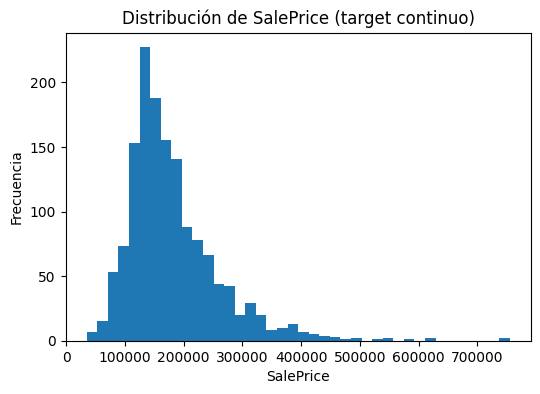

SalePrice valores únicos: 663
Ejemplos de precios: [np.int64(34900), np.int64(35311), np.int64(37900), np.int64(39300), np.int64(40000)] ... [np.int64(582933), np.int64(611657), np.int64(625000), np.int64(745000), np.int64(755000)]


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df[TARGET], bins=40)
plt.title("Distribución de SalePrice (target continuo)")
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.show()

print("SalePrice valores únicos:", df[TARGET].nunique())
print("Ejemplos de precios:", sorted(df[TARGET].unique())[:5], "...", sorted(df[TARGET].unique())[-5:])


In [ ]:
# Creamos clases artificiales por terciles (solo para demostrar)
q1, q2 = df[TARGET].quantile([0.33, 0.66])

def price_class(p):
    if p <= q1: return "bajo"
    if p <= q2: return "medio"
    return "alto"

df["PriceClass"] = df[TARGET].apply(price_class)
df["PriceClass"].value_counts()


,count
PriceClass,
alto,497
bajo,483
medio,480


**Preprocesamiento**

imputación + one-hot + escalado

In [ ]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

num_cols = ["YrSold", "LotArea", "OverallCond"]
cat_cols = ["Utilities", "LandContour", "Alley"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para Alley es muy común usar "NoAlley" como categoría faltante
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="NoAlley")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Entrenamiento Arbol-Knn**

arbol de regresión

In [ ]:
tree_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_grid = {
    "model__max_depth": [3, 4, 5, 6, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__min_samples_split": [2, 10, 20, 50],
}

gs_tree = GridSearchCV(tree_pipe, tree_grid, scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
gs_tree.fit(X_train, y_train)

best_tree = gs_tree.best_estimator_
pred_tree = best_tree.predict(X_test)

print("TREE best params:", gs_tree.best_params_)
print("TREE MAE:", mean_absolute_error(y_test, pred_tree))
print("TREE RMSE:", np.sqrt(mean_squared_error(y_test, pred_tree)))
print("TREE R2:", r2_score(y_test, pred_tree))

TREE best params: {'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
TREE MAE: 48084.05027179939
TREE RMSE: 71814.88855645682
TREE R2: 0.3276194415898729


Knn de regresion

In [ ]:
knn_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", KNeighborsRegressor())
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 15, 25, 35],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan / Euclidiana
}

gs_knn = GridSearchCV(knn_pipe, knn_grid, scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
gs_knn.fit(X_train, y_train)

best_knn = gs_knn.best_estimator_
pred_knn = best_knn.predict(X_test)

print("KNN best params:", gs_knn.best_params_)
print("KNN MAE:", mean_absolute_error(y_test, pred_knn))
print("KNN RMSE:", np.sqrt(mean_squared_error(y_test, pred_knn)))
print("KNN R2:", r2_score(y_test, pred_knn))

KNN best params: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'uniform'}
KNN MAE: 51562.39589041096
KNN RMSE: 75801.95417249165
KNN R2: 0.25088762835346445


Mapeo de colores

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


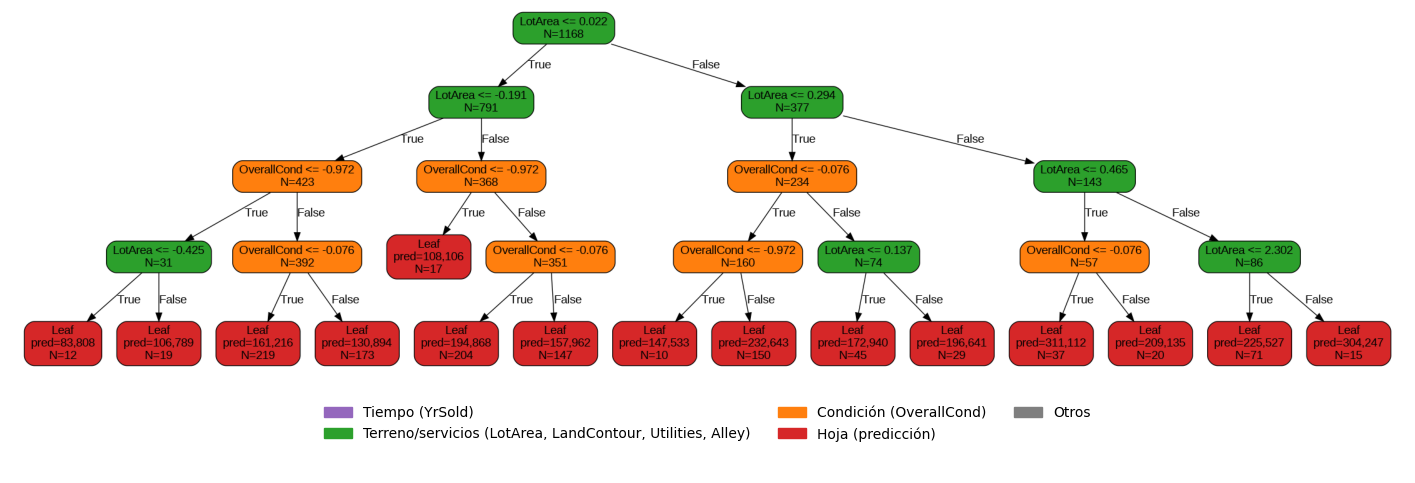

In [ ]:
# =========================
# Código completo: Árbol + leyenda SIN superposición (2 ejes)
# Requiere que ya existan: preprocess, X_train, y_train, num_cols, cat_cols
# =========================
from graphviz import Source
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
import io

# =========================
# Colores
# =========================
COLORS = {
    "time": "#9467bd",       # purple
    "terrain": "#2ca02c",    # green
    "condition": "#ff7f0e",  # orange
    "leaf": "#d62728",       # red
    "other": "#7f7f7f"       # gray
}

# =========================
# Entrenar árbol pequeño para visualización
# =========================
viz_tree = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=4, min_samples_leaf=10))
])
viz_tree.fit(X_train, y_train)

# Feature names (num + onehot)
pre = viz_tree.named_steps["prep"]

# Robusto: "cat" puede ser Pipeline (con onehot) o el encoder directo
cat_tx = pre.named_transformers_["cat"]
ohe = cat_tx.named_steps["onehot"] if hasattr(cat_tx, "named_steps") else cat_tx

feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

sk_tree = viz_tree.named_steps["model"]
t = sk_tree.tree_

def tag_feature(feat_name: str) -> str:
    # OneHotEncoder produce: "LandContour_Lvl", "Utilities_AllPub", etc.
    if feat_name.startswith("YrSold"):
        return "time"
    if feat_name.startswith(("LotArea", "LandContour", "Utilities", "Alley")):
        return "terrain"
    if feat_name.startswith("OverallCond"):
        return "condition"
    return "other"

def tree_to_dot_colored(tree_, feature_names, colors_dict):
    """Genera DOT para Graphviz con fillcolor por tag."""
    lines = []
    lines.append('digraph Tree {')
    lines.append('node [shape=box, style="filled,rounded", fontname="Helvetica"];')
    lines.append('edge [fontname="Helvetica"];')

    for i in range(tree_.node_count):
        if tree_.feature[i] == -2:  # leaf
            pred = tree_.value[i][0][0]
            n = tree_.n_node_samples[i]
            fill = colors_dict["leaf"]
            label = f"Leaf\\npred={pred:,.0f}\\nN={n}"
        else:
            feat = feature_names[tree_.feature[i]]
            thr = tree_.threshold[i]
            n = tree_.n_node_samples[i]
            fill = colors_dict[tag_feature(feat)]
            label = f"{feat} <= {thr:.3f}\\nN={n}"

        lines.append(f'{i} [label="{label}", fillcolor="{fill}"];')

        L = tree_.children_left[i]
        R = tree_.children_right[i]
        if L != -1:
            lines.append(f'{i} -> {L} [label="True"];')
        if R != -1:
            lines.append(f'{i} -> {R} [label="False"];')

    lines.append("}")
    return "\n".join(lines)

# =========================
# Render árbol (Graphviz -> PNG)
# =========================
dot = tree_to_dot_colored(t, feature_names, COLORS)
src = Source(dot)
png_bytes = src.pipe(format="png")
img = Image.open(io.BytesIO(png_bytes))

# =========================
# Leyenda
# =========================
legend_items = [
    mpatches.Patch(color=COLORS["time"], label="Tiempo (YrSold)"),
    mpatches.Patch(color=COLORS["terrain"], label="Terreno/servicios (LotArea, LandContour, Utilities, Alley)"),
    mpatches.Patch(color=COLORS["condition"], label="Condición (OverallCond)"),
    mpatches.Patch(color=COLORS["leaf"], label="Hoja (predicción)"),
    mpatches.Patch(color=COLORS["other"], label="Otros"),
]

# =========================
# Mostrar: 2 ejes (árbol arriba, leyenda abajo) -> NO se sobrepone
# =========================
w, h = img.size
fig_w = 18
tree_h = fig_w * (h / w)  # altura proporcional al png del árbol
legend_h = 1.3            # franja fija para la leyenda (sube si la quieres más grande)
fig_h = tree_h + legend_h

fig, (ax_tree, ax_leg) = plt.subplots(
    2, 1,
    figsize=(fig_w, fig_h),
    gridspec_kw={"height_ratios": [tree_h, legend_h], "hspace": 0.02}
)

# Árbol
ax_tree.imshow(img)
ax_tree.axis("off")

# Leyenda (en su propio eje)
ax_leg.axis("off")
ax_leg.legend(
    handles=legend_items,
    ncol=3,          # si la quieres en una sola fila: ncol=5
    frameon=False,
    loc="center"
)

plt.show()


knn

LINEAR REGRESSION (para explicación/presentación)
MAE : 60075.92592291177
RMSE: 84155.06141329266
R2  : 0.0766918941675353


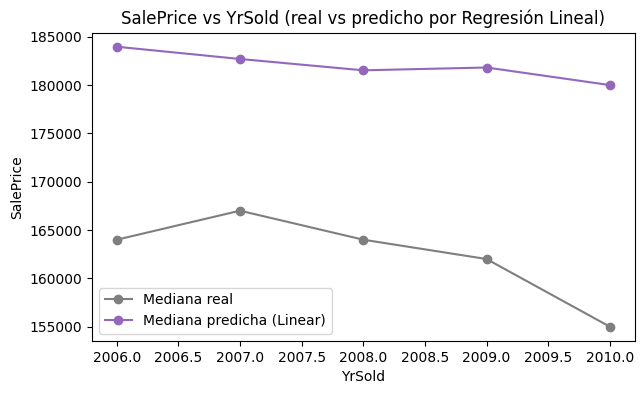

,YrSold,SalePrice,PredPrice,Delta_1Y_pred
0,2006,163995.0,183956.166268,-1267.900413
1,2007,167000.0,182688.265856,-1172.815988
2,2008,164000.0,181515.449868,291.889363
3,2009,162000.0,181807.339231,-1818.175047
4,2010,155000.0,179989.164184,NaN


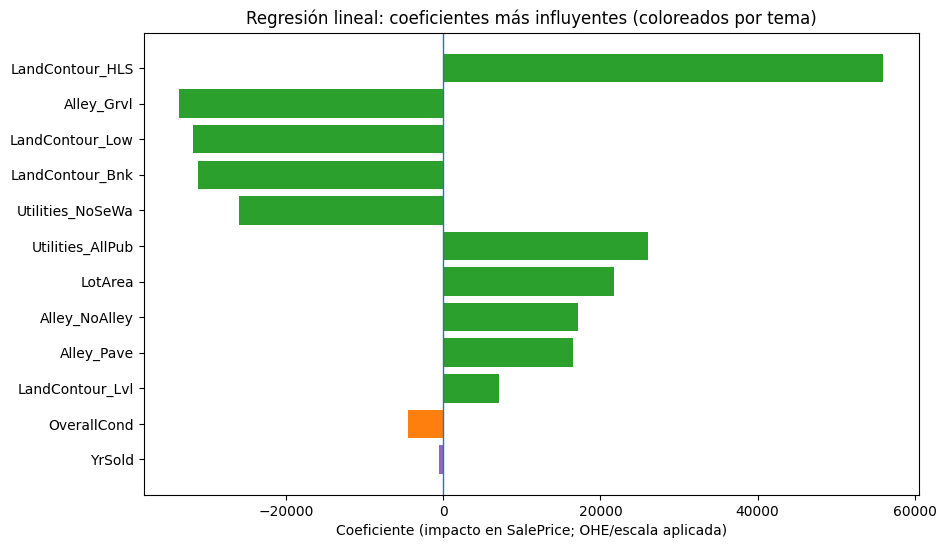

,feature,coef,tag
6,LandContour_HLS,56025.547683,terrain
9,Alley_Grvl,-33702.267863,terrain
7,LandContour_Low,-31867.064132,terrain
5,LandContour_Bnk,-31209.276012,terrain
4,Utilities_NoSeWa,-26065.280712,terrain
3,Utilities_AllPub,26065.280712,terrain
1,LotArea,21757.661795,terrain
10,Alley_NoAlley,17177.338253,terrain
11,Alley_Pave,16524.929610,terrain
8,LandContour_Lvl,7050.792462,terrain


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 0) Fallback de colores si no existe COLORS en tu notebook
# ---------------------------------------------------------
try:
    COLORS
except NameError:
    COLORS = {
        "time": "tab:purple",
        "terrain": "tab:green",
        "condition": "tab:orange",
        "leaf": "tab:red",
        "other": "tab:gray"
    }

# ---------------------------------------------------------
# 1) Entrenar REGRESIÓN LINEAL con el MISMO preprocess
# ---------------------------------------------------------
lin_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_train)
pred_lin = lin_pipe.predict(X_test)

print("LINEAR REGRESSION (para explicación/presentación)")
print("MAE :", mean_absolute_error(y_test, pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lin)))
print("R2  :", r2_score(y_test, pred_lin))

# ---------------------------------------------------------
# 2) Helper: tag por tema (usa tus variables importantes)
# ---------------------------------------------------------
def tag_feature_lr(feat_name: str) -> str:
    # OHE produce nombres como "LandContour_Lvl", "Utilities_AllPub", etc.
    if feat_name.startswith("YrSold"):
        return "time"
    if feat_name.startswith(("LotArea", "LandContour", "Utilities", "Alley")):
        return "terrain"
    if feat_name.startswith("OverallCond"):
        return "condition"
    return "other"

# ---------------------------------------------------------
# 3) Gráfica A: tendencia por año (YrSold) -> muy útil para Q1
#     Mediana real vs mediana predicha por año
# ---------------------------------------------------------
df_pred = pd.DataFrame({
    "YrSold": X["YrSold"].values,
    "SalePrice": y.values,
    "PredPrice": lin_pipe.predict(X)
})

year_summary = df_pred.groupby("YrSold")[["SalePrice", "PredPrice"]].median().reset_index()

plt.figure(figsize=(7,4))
plt.plot(year_summary["YrSold"], year_summary["SalePrice"], marker="o",
         label="Mediana real", color=COLORS["other"])
plt.plot(year_summary["YrSold"], year_summary["PredPrice"], marker="o",
         label="Mediana predicha (Linear)", color=COLORS["time"])
plt.title("SalePrice vs YrSold (real vs predicho por Regresión Lineal)")
plt.xlabel("YrSold")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

# Delta 1 año (mediana) usando la curva predicha (para explicar “cambio en 1 año”)
year_summary["Delta_1Y_pred"] = year_summary["PredPrice"].shift(-1) - year_summary["PredPrice"]
display(year_summary)

# ---------------------------------------------------------
# 4) Gráfica B: Coeficientes más influyentes (coloreados por tema)
# ---------------------------------------------------------
pre = lin_pipe.named_steps["prep"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))
coefs = lin_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df["tag"] = coef_df["feature"].apply(tag_feature_lr)

top = coef_df.sort_values("abs_coef", ascending=False).head(15).copy()
bar_colors = [COLORS[t] for t in top["tag"]]

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["coef"], color=bar_colors)
plt.axvline(0, linewidth=1)
plt.title("Regresión lineal: coeficientes más influyentes (coloreados por tema)")
plt.xlabel("Coeficiente (impacto en SalePrice; OHE/escala aplicada)")
plt.gca().invert_yaxis()
plt.show()

display(top[["feature","coef","tag"]])



**Preguntas**

¿Cómo varía el valor al cabo de 1 año?

Δ 1 año (TREE) mediana: 0.0 promedio: 0.0
Δ 1 año (KNN)  mediana: 0.0 promedio: 2176.7224200913247


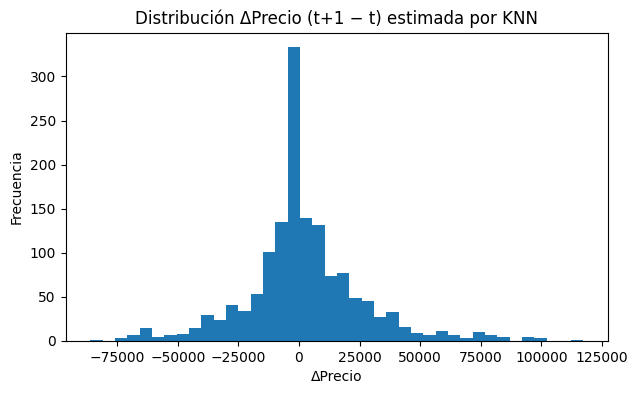

In [ ]:
def delta_1_year(model_pipe, Xraw):
    X_next = Xraw.copy()
    X_next["YrSold"] = X_next["YrSold"] + 1
    return model_pipe.predict(X_next) - model_pipe.predict(Xraw)

d_tree = delta_1_year(best_tree, X)
d_knn  = delta_1_year(best_knn, X)

print("Δ 1 año (TREE) mediana:", np.median(d_tree), "promedio:", np.mean(d_tree))
print("Δ 1 año (KNN)  mediana:", np.median(d_knn),  "promedio:", np.mean(d_knn))

plt.figure(figsize=(7,4))
plt.hist(d_knn, bins=40)
plt.title("Distribución ΔPrecio (t+1 − t) estimada por KNN")
plt.xlabel("ΔPrecio")
plt.ylabel("Frecuencia")
plt.show()


¿Cómo afecta el tipo de terreno/servicios del lote en la “depreciación/valor”?

In [ ]:
# Mediana de precio por tipo de terreno
display(df.groupby("LandContour")["SalePrice"].median().sort_values(ascending=False).to_frame("median_price"))

# Mediana de precio por Alley (incluyendo faltantes)
display(df["Alley"].fillna("NoAlley").groupby(df["Alley"].fillna("NoAlley")).apply(lambda s: df.loc[s.index,"SalePrice"].median()).to_frame("median_price"))

# Utilities está casi todo en un solo valor, igual lo mostramos
display(df.groupby("Utilities")["SalePrice"].median().sort_values(ascending=False).to_frame("median_price"))

# LotArea: relación continua (correlación simple)
corr = df["LotArea"].corr(df["SalePrice"])
print("Correlación LotArea vs SalePrice:", corr)


,median_price
LandContour,
HLS,222250.0
Low,190000.0
Lvl,162900.0
Bnk,139400.0


,median_price
Alley,
Grvl,119500.0
NoAlley,165000.0
Pave,172500.0


,median_price
Utilities,
AllPub,163000.0
NoSeWa,137500.0


Correlación LotArea vs SalePrice: 0.2638433538714056


¿Cómo el “crecimiento” afecta el valor?

,median_price_by_year
YrSold,
2006,163995.0
2007,167000.0
2008,164000.0
2009,162000.0
2010,155000.0


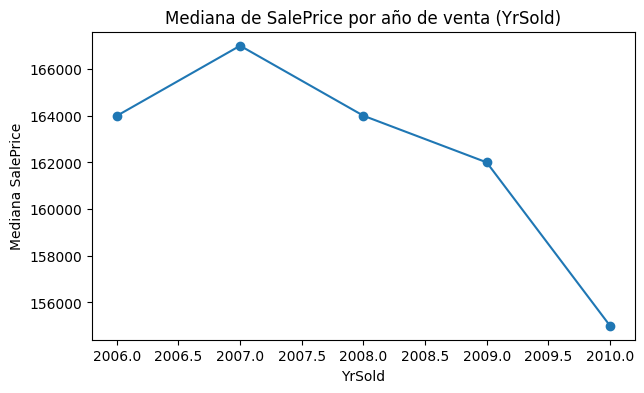

In [ ]:
year_median = df.groupby("YrSold")["SalePrice"].median()
display(year_median.to_frame("median_price_by_year"))

plt.figure(figsize=(7,4))
plt.plot(year_median.index, year_median.values, marker="o")
plt.title("Mediana de SalePrice por año de venta (YrSold)")
plt.xlabel("YrSold")
plt.ylabel("Mediana SalePrice")
plt.show()


¿Cómo la condición general influye en el valor?

In [ ]:
display(df.groupby("OverallCond")["SalePrice"].median().sort_values(ascending=False).to_frame("median_price"))

,median_price
OverallCond,
5,185000.0
9,176200.0
7,145000.0
6,142750.0
8,142500.0
4,115000.0
3,89500.0
2,85000.0
1,61000.0
